# Accumulation to rate examples

Below are provides several examples which attempt to cover the range of accumulation types that you may come across when working with ECMWF data. Please refer to the [ECMWF documentation](https://confluence.ecmwf.int/x/hrTICw) for a detailed summary of the accumulation types.

Please refer to the [Accumulation to rate tutorial](https://earthkit-transforms.readthedocs.io/en/latest/tutorials/temporal/05-accumulation-to-rate-examples.html) for a more detailed version of these examples.

In [1]:
from earthkit import data as ekd
from earthkit import transforms as ekt
from earthkit import plots as ekp
from earthkit.transforms._tools import earthkit_remote_test_data_file

## Accumulated from start of step (e.g. ERA5)

ERA5 accumulates data from the start of each time step, therefore the conversion to rate is a division by the time step length.
We no longer need to think about the details, the `temporal.accumulation_to_rate` will figure this out for you.
We only specify the `accumulation_type`.

Note, that this assumes that your data is contiguous in time. If you data is irregular you can provide
additional data to account for this.

In [22]:
era5_data = ekd.from_source("url", earthkit_remote_test_data_file("era5-sfc-precip-3deg-202401.grib"))
# Open the data with xarray using the valid_time time dimension mode.
ds_era5 = era5_data.to_xarray(time_dims=["valid_time"])

ds_era5_rate = ekt.temporal.accumulation_to_rate(ds_era5, accumulation_type="start_of_step")
ds_era5_rate

<xarray.Dataset> Size: 3MB
Dimensions:     (valid_time: 744, latitude: 19, longitude: 29)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2024-01-01 ... 2024-01-31T23:...
  * latitude    (latitude) float64 152B 79.0 76.0 73.0 70.0 ... 31.0 28.0 25.0
  * longitude   (longitude) float64 232B -25.0 -22.0 -19.0 ... 53.0 56.0 59.0
Data variables:
    tp_rate     (valid_time, latitude, longitude) float64 3MB 0.0 0.0 ... 0.0
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

The returned `xarray.Dataset` has a `tp_rate` data variable, this automatic suffix can be changed or suppressed using the `rate_label` kwarg in the function call.

By inspecting the attributes of the `tp_rate` variable above you can see that the units and long_name have been updated to describe the rate data.

Additionally, a history attribute has been added describing the that data has been converted from an accumulation to a rate. This can be surpressed by setting `provenance=False` in the function call.

All other variable and dataset attributes have been removed, this is intentional as it cannot be guarenteed that they are still valid for the rate data.

We can plot the effect of our computation using `earthkit.plots`. Below, the accumulated data as a bar chart (blue) and the rate data as line (orange). As the data is accumulated since the start of step, this change is just a change in units, which is evident by the identical shapes of the bars and line.

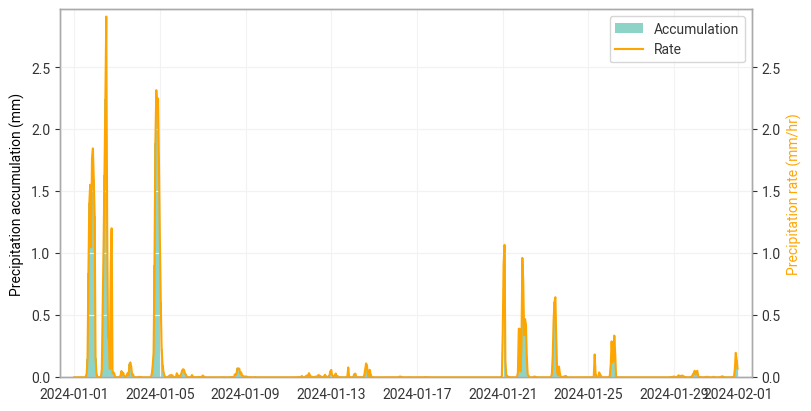

In [ ]:
plot_point = {"latitude": 52, "longitude": -1}

chart = ekp.TimeSeries()
chart.bar(
    ds_era5.sel(plot_point, method="nearest"),
    units="mm", label="Accumulation", width=0.1, lw=0,
)
chart.ylabel("Precipitation accumulation (mm)")
chart2 = chart.twinx()
chart2.line(
    ds_era5_rate.sel(plot_point, method="nearest"),
    units="mm/hr", label="Rate", color="orange"
)
chart2.ylabel("Precipitation rate (mm/hr)", color="orange")
chart2.ax.set_ylim(0, None)
chart.legend()
chart.show()


## Daily accumulation (e.g. ERA5-Land)

The [ERA5-land](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land) is accumulated from the start of each day, which makes it a particularly tricky example as we must intricately deaccumulate the data then convert to a rate. Luckily, all this is simplified using the accumulation_to_rate function where all we need to provide is `accumulation_type="start_of_day"`

In [25]:
era5land_data = ekd.from_source("url", earthkit_remote_test_data_file("era5-land-precip-3deg-202401.grib"))
ds_era5land = era5land_data.to_xarray(time_dims=["valid_time"])

ds_era5land_rate = ekt.temporal.accumulation_to_rate(ds_era5land, accumulation_type="start_of_day")
ds_era5land_rate

Please be aware that using accumulation_type='start_of_day' with a 'valid_time' representation assumes that the data is contiguous with steps that can be identified as midnight in order to reset accumulation.


<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 743, latitude: 19, longitude: 34)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2024-01-01T01:00:00 ... 2024-...
  * latitude    (latitude) float64 152B 79.0 76.0 73.0 70.0 ... 31.0 28.0 25.0
  * longitude   (longitude) float64 272B -20.0 -17.0 -14.0 ... 73.0 76.0 79.0
Data variables:
    tp_rate     (valid_time, latitude, longitude) float64 4MB 0.0 nan ... 0.0
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

As with the previous example, the output contains a `tp_rate` variable where the units and long_name attributes have been updated to describe the rate data, and a history attribute added.

You will also see that the `valid_time` dimension is one less than provided in the input. This is because the function does not know what came before the first time step. If we know that the first step starts from zero, then we can set `from_first_step=True`, we demonstrate this in the next, seasonal forecast, example as it is not valid here.

Below we plot the accumulation and rate data on the same axis using the same styling as the previous example. This time the effect of the accumulation to rate is more evident as there is both a deaccumulation and a unit conversion applied. Dashed vertical lines at the start of each day have been included to demonstrate the restart of the accumulated precipitation.


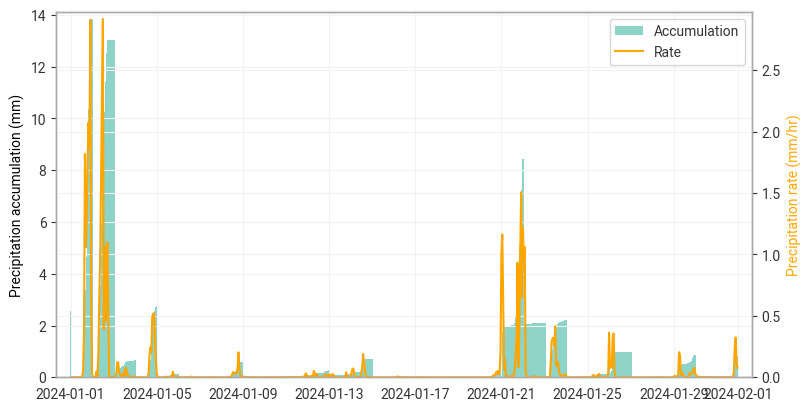

In [27]:
plot_point = {"latitude": 52, "longitude": -1}

chart = ekp.TimeSeries()
chart.bar(
    ds_era5land.sel(plot_point, method="nearest"),
    units="mm", label="Accumulation", width=0.1, lw=0,
)
chart.ylabel("Precipitation accumulation (mm)")
chart2 = chart.twinx()
chart2.line(
    ds_era5land_rate.sel(plot_point, method="nearest"),
    units="mm/hr", label="Rate", color="orange"
)
chart2.ylabel("Precipitation rate (mm/hr)", color="orange")
chart2.ax.set_ylim(0, None)
chart.legend()
chart.show()

## Accumulated from start of forecast (e.g. Seasonal forecasts)

Seasonal forecast data is accumulated from the start of each forecast initialisation,
therefore we need to deaccumulate the data and then convert to a rate.
It is common place for forecast data to include multiple forecast initialisations in a single file,
therefore in the example below we will use the default
`time_dims=["forecast_reference_time", "step"]` representation of the data.

In this example we use some sample total precipitation data from the
[Seasonal forecast daily and subdaily dataset](https://cds.climate.copernicus.eu/datasets/seasonal-original-single-levels).
It provides 60 days of daily data for two forecasts, initialised January 1st and February 1st 2024,
over Europe at 3˚ⅹ3˚spatial resolution.

To calculate the rate we just set `accumulation_type="start_of_forecast"`, and we can use the function like we
did in our previous examples. However, as we know that the accumulation of the first time step is from zero,
we can set `from_first_step=True` so that the result includes the first time step.

In [31]:
seas5_data = ekd.from_source("url", earthkit_remote_test_data_file("seas5-precip-3deg-202401-202402.grib"))
ds_seas5 = seas5_data.to_xarray(add_valid_time_coord=True)

ds_seas5_rate = ekt.temporal.accumulation_to_rate(
    ds_seas5,
    accumulation_type="start_of_forecast",
    from_first_step=True
)
ds_seas5_rate

<xarray.Dataset> Size: 32MB
Dimensions:                  (member: 51, forecast_reference_time: 2, step: 60,
                              latitude: 19, longitude: 34)
Coordinates:
  * member                   (member) <U2 408B '0' '1' '10' '11' ... '7' '8' '9'
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 16B 202...
  * step                     (step) timedelta64[ns] 480B 1 days ... 60 days
    valid_time               (forecast_reference_time, step) datetime64[ns] 960B ...
  * latitude                 (latitude) float64 152B 79.0 76.0 ... 28.0 25.0
  * longitude                (longitude) float64 272B -20.0 -17.0 ... 76.0 79.0
Data variables:
    tp_rate                  (step, member, forecast_reference_time, latitude, longitude) float64 32MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

Below is a plot of the accumulated vs rate data for the two forecast initialisations in the file, January and February 2024.

In [62]:
help(chart.legend)


Help on method legend in module earthkit.plots.components.subplots:

legend(label=None, *args, **kwargs) method of earthkit.plots.temporal.timeseries.TimeSeries instance
    Add a legend to the Subplot.

    Parameters
    ----------
    style : Style, optional
        The Style to use for the legend. If None (default), a legend is
        created for each Layer with a unique Style. If a single Style is
        provided, a single legend is created based on that Style.
    location : str or tuple, optional
        The location of the legend(s). Must be a valid matplotlib location
        (see :func:`matplotlib.pyplot.legend`).
    **kwargs
        Additional keyword arguments to pass to :func:`matplotlib.pyplot.legend`.



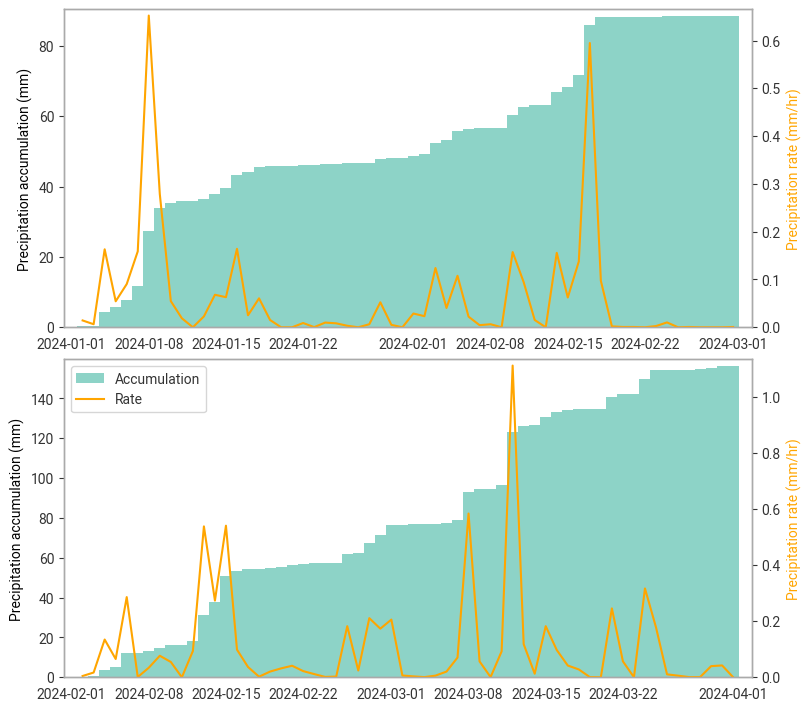

In [72]:
plot_point = {"latitude": 49, "longitude": 34}

figure = ekp.Figure(rows=2, columns=1)
for i in range(2):
    chart = figure.add_timeseries()
    chart.bar(
        ds_seas5.sel(plot_point, method="nearest").isel(member=0, forecast_reference_time=i),
        x="valid_time",
        units="mm", label="Accumulation", width=1., lw=0,
    )
    chart.ylabel("Precipitation accumulation (mm)")
    chart.ax.grid(False)
    chart2 = chart.twinx()
    chart2.line(
        ds_seas5_rate.sel(plot_point, method="nearest").isel(member=0, forecast_reference_time=i),
        x="valid_time",
        units="mm/hr", label="Rate", color="orange"
    )
    chart2.ylabel("Precipitation rate (mm/hr)", color="orange")
    chart2.ax.set_ylim(0, None)
    chart2.ax.grid(False)

chart.legend()

figure.show()

## Deaccumulate only

Deaccumulation of data is akin to converting to a rate where the units of the rate are equivalent to the length of the time step. This can be done using the `earthkit.transforms.temporal.deaccumulate` function, as demonstrated below.

ℹ️ **Note:** The deaccumulation function is a wrapper of the accumulation_to_rate function with `rate_units="step_length"`.

The example below uses the same seasonal forecast data as the previous example, and deaccumulates the total precipitation such that is represents the accumulation of a single time-step. Comparable with the native ERA5 data in the first example.

In [74]:
ds_seas5_deaccumulate = ekt.temporal.deaccumulate(ds_seas5, accumulation_type="start_of_forecast", from_first_step=True)
ds_seas5_deaccumulate

<xarray.Dataset> Size: 32MB
Dimensions:                  (member: 51, forecast_reference_time: 2, step: 60,
                              latitude: 19, longitude: 34)
Coordinates:
  * member                   (member) <U2 408B '0' '1' '10' '11' ... '7' '8' '9'
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 16B 202...
  * step                     (step) timedelta64[ns] 480B 1 days ... 60 days
    valid_time               (forecast_reference_time, step) datetime64[ns] 960B ...
  * latitude                 (latitude) float64 152B 79.0 76.0 ... 28.0 25.0
  * longitude                (longitude) float64 272B -20.0 -17.0 ... 76.0 79.0
Data variables:
    tp                       (step, member, forecast_reference_time, latitude, longitude) float64 32MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

Below is a plot of the accumulated and de-accumulated data for the two forecast initialisations in the file, January and February 2024. 
The plot demonstrates that the deaccumulation is the same as the rate calculated with the previous example but with differing units.

/Users/edwardcomyn-platt/Work/Git_Repositories/ecmwf-training/2026-earthkit-training/.conda/lib/python3.12/site-packages/earthkit/plots/sources/__init__.py:273: UserWarning: Unit conversion failed for y: meter -> mm/hr. Error: Cannot convert from 'meter' ([length]) to 'millimeter / hour' ([length] / [time]). Returning original values.
  warnings.warn(


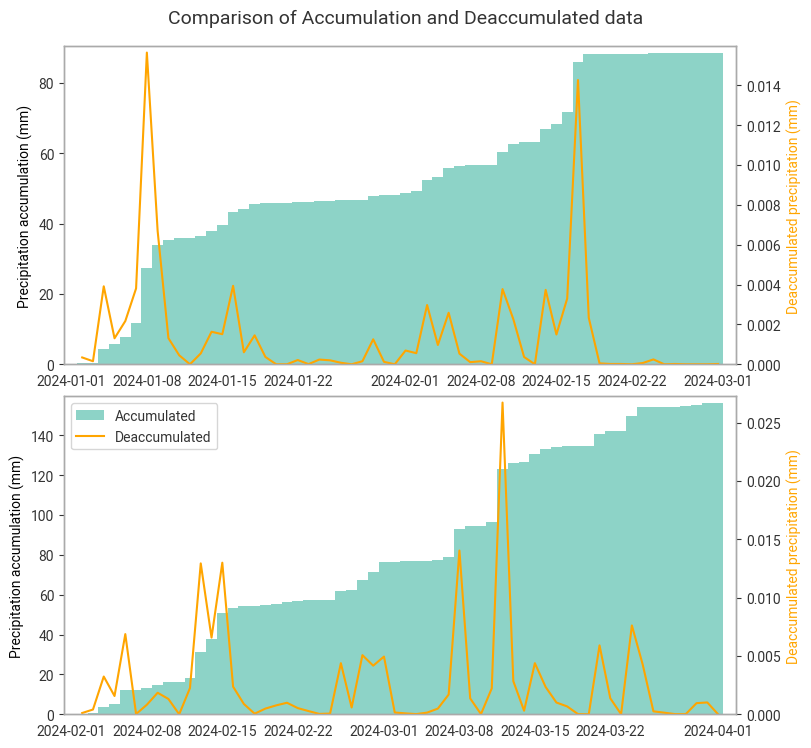

In [80]:
plot_point = {"latitude": 49, "longitude": 34}

figure = ekp.Figure(rows=2, columns=1)
for i in range(2):
    chart = figure.add_timeseries()
    chart.bar(
        ds_seas5.sel(plot_point, method="nearest").isel(member=0, forecast_reference_time=i),
        x="valid_time",
        units="mm", label="Accumulated", width=1., lw=0,
    )
    chart.ylabel("Precipitation accumulation (mm)")
    chart.ax.grid(False)
    chart2 = chart.twinx()
    chart2.line(
        ds_seas5_deaccumulate.sel(plot_point, method="nearest").isel(member=0, forecast_reference_time=i),
        x="valid_time",
        units="mm/hr", label="Deaccumulated", color="orange"
    )
    chart2.ylabel("Deaccumulated precipitation (mm)", color="orange")
    chart2.ax.set_ylim(0, None)
    chart2.ax.grid(False)

chart.legend()

figure.title("Comparison of Accumulation and Deaccumulated data")
figure.show()